In [1]:
# =====================================
# TELECOM CUSTOMER CHURN PREDICTION
# =====================================

# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [11]:
df = pd.read_csv("data/customer_churn_cleaned.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [14]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
numAdminTickets      0
numTechTickets       0
Churn                0
Churn_Flag           0
TenureGroup         11
ChargeSegment        0
Revenue              0
dtype: int64

In [15]:
# Fill missing TotalCharges with the median

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [19]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 36, 48, 60, 72],
    labels=[
        "<1 Year",
        "<2 Year",
        "<3 Year",
        "<4 Year",
        "<5 Year",
        "<6 Year"
    ],
    include_lowest=True
)

In [21]:
df["TenureGroup"].isnull().sum()

np.int64(0)

In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
numAdminTickets     0
numTechTickets      0
Churn               0
Churn_Flag          0
TenureGroup         0
ChargeSegment       0
Revenue             0
dtype: int64

In [23]:
# Make a copy
df_fe = df.copy()

# -------------------------------------------
# 1. Remove unnecessary columns
# -------------------------------------------

df_fe.drop(
    columns=["customerID", "Churn_Flag"],
    inplace=True
)

# -------------------------------------------
# 2. Create Average Monthly Spend
# -------------------------------------------

df_fe["AvgMonthlySpend"] = (
    df_fe["TotalCharges"] /
    (df_fe["tenure"] + 1)
)

# -------------------------------------------
# 3. Total Services Used
# -------------------------------------------

service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_columns:
    df_fe[col] = df_fe[col].replace(
        {
            "Yes": 1,
            "No": 0,
            "No internet service": 0,
            "No phone service": 0
        }
    )

df_fe["TotalServices"] = df_fe[service_columns].sum(axis=1)

# -------------------------------------------
# 4. High Value Customer
# -------------------------------------------

df_fe["HighValueCustomer"] = np.where(
    df_fe["MonthlyCharges"] >
    df_fe["MonthlyCharges"].median(),
    1,
    0
)

# -------------------------------------------
# 5. Long Term Customer
# -------------------------------------------

df_fe["LongTermCustomer"] = np.where(
    df_fe["tenure"] >= 24,
    1,
    0
)

# -------------------------------------------
# 6. Revenue Per Month
# -------------------------------------------

df_fe["RevenuePerMonth"] = (
    df_fe["Revenue"] /
    (df_fe["tenure"] + 1)
)

# -------------------------------------------
# 7. Support Ticket Ratio
# -------------------------------------------

df_fe["SupportTicketRatio"] = (
    (df_fe["numAdminTickets"] +
     df_fe["numTechTickets"])
    /
    (df_fe["tenure"] + 1)
)

# -------------------------------------------
# 8. Total Tickets
# -------------------------------------------

df_fe["TotalTickets"] = (
    df_fe["numAdminTickets"] +
    df_fe["numTechTickets"]
)

# -------------------------------------------
# 9. Ticket Per Service
# -------------------------------------------

df_fe["TicketPerService"] = (
    df_fe["TotalTickets"] /
    (df_fe["TotalServices"] + 1)
)

# -------------------------------------------
# 10. Monthly Charge Category
# -------------------------------------------

df_fe["ChargeCategory"] = pd.cut(
    df_fe["MonthlyCharges"],
    bins=[0,35,70,120],
    labels=["Low","Medium","High"]
)

# -------------------------------------------
# 11. Tenure Category
# -------------------------------------------

df_fe["TenureCategory"] = pd.cut(
    df_fe["tenure"],
    bins=[-1,12,24,48,72],
    labels=[
        "New",
        "Growing",
        "Loyal",
        "Very Loyal"
    ]
)

# -------------------------------------------
# 12. Customer Lifetime Value
# -------------------------------------------

df_fe["CustomerLifetimeValue"] = (
    df_fe["MonthlyCharges"] *
    df_fe["tenure"]
)

# -------------------------------------------
# Check new columns
# -------------------------------------------

print(df_fe.head())

print(df_fe.shape)

   gender  SeniorCitizen Partner Dependents  tenure  PhoneService  \
0  Female              0     Yes         No       1             0   
1    Male              0      No         No      34             1   
2    Male              0      No         No       2             1   
3    Male              0      No         No      45             0   
4  Female              0      No         No       2             1   

   MultipleLines InternetService  OnlineSecurity  OnlineBackup  ...  \
0              0             DSL               0             1  ...   
1              0             DSL               1             0  ...   
2              0             DSL               1             1  ...   
3              0             DSL               1             0  ...   
4              0     Fiber optic               0             0  ...   

   TotalServices  HighValueCustomer  LongTermCustomer  RevenuePerMonth  \
0              1                  0                 0        14.925000   
1         

C:\Users\HP\AppData\Local\Temp\ipykernel_8556\3023393295.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_fe[col] = df_fe[col].replace(


In [24]:
# Separate Features & Target

X = df_fe.drop("Churn", axis=1)

y = df_fe["Churn"]

# Encode

X = pd.get_dummies(
    X,
    drop_first=True
)

# Encode Target

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(X.shape)
print(y.shape)

(7043, 48)
(7043,)


In [25]:
# ==========================================
# Train Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (5634, 48)
Testing Features  : (1409, 48)
Training Labels   : (5634,)
Testing Labels    : (1409,)


In [26]:
# ==========================================
# Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


c:\Users\HP\anaconda3\envs\biopy\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
# Predict

y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:,1]

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))

print("Precision :", precision_score(y_test, y_pred_lr))

print("Recall :", recall_score(y_test, y_pred_lr))

print("F1 Score :", f1_score(y_test, y_pred_lr))

print("ROC AUC :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.8694109297374024
Precision : 0.7827380952380952
Recall : 0.7032085561497327
F1 Score : 0.7408450704225352
ROC AUC : 0.931447466997339


In [29]:
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[962  73]
 [111 263]]


In [30]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1035
           1       0.78      0.70      0.74       374

    accuracy                           0.87      1409
   macro avg       0.84      0.82      0.83      1409
weighted avg       0.87      0.87      0.87      1409



In [31]:
# ==========================================
# Decision Tree
# ==========================================

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [32]:
print("="*60)
print("Decision Tree")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision :", precision_score(y_test, y_pred_dt))
print("Recall :", recall_score(y_test, y_pred_dt))
print("F1 :", f1_score(y_test, y_pred_dt))
print("ROC AUC :", roc_auc_score(y_test, y_prob_dt))

Decision Tree
Accuracy : 0.8573456352022711
Precision : 0.764525993883792
Recall : 0.6684491978609626
F1 : 0.7132667617689016
ROC AUC : 0.9147045906636698


In [33]:
# ==========================================
# Random Forest
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=8
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [34]:
print("="*60)
print("Random Forest")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall :", recall_score(y_test, y_pred_rf))
print("F1 :", f1_score(y_test, y_pred_rf))
print("ROC AUC :", roc_auc_score(y_test, y_prob_rf))

Random Forest
Accuracy : 0.865152590489709
Precision : 0.7875
Recall : 0.6737967914438503
F1 : 0.7262247838616714
ROC AUC : 0.9299633160246971


In [35]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison = comparison.round(3)
print(comparison)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression     0.869      0.783   0.703     0.741    0.931
1        Decision Tree     0.857      0.765   0.668     0.713    0.915
2        Random Forest     0.865      0.788   0.674     0.726    0.930


In [36]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lr.coef_[0]
})

importance["Importance"] = importance["Importance"].abs()

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
13,numTechTickets,0.897900
30,Contract_Two year,0.703699
3,MultipleLines,0.679993
2,PhoneService,0.594993
29,Contract_One year,0.500812
31,PaperlessBilling_Yes,0.491168
21,TotalTickets,0.461727
12,numAdminTickets,0.436173
28,InternetService_No,0.427305
4,OnlineSecurity,0.370530


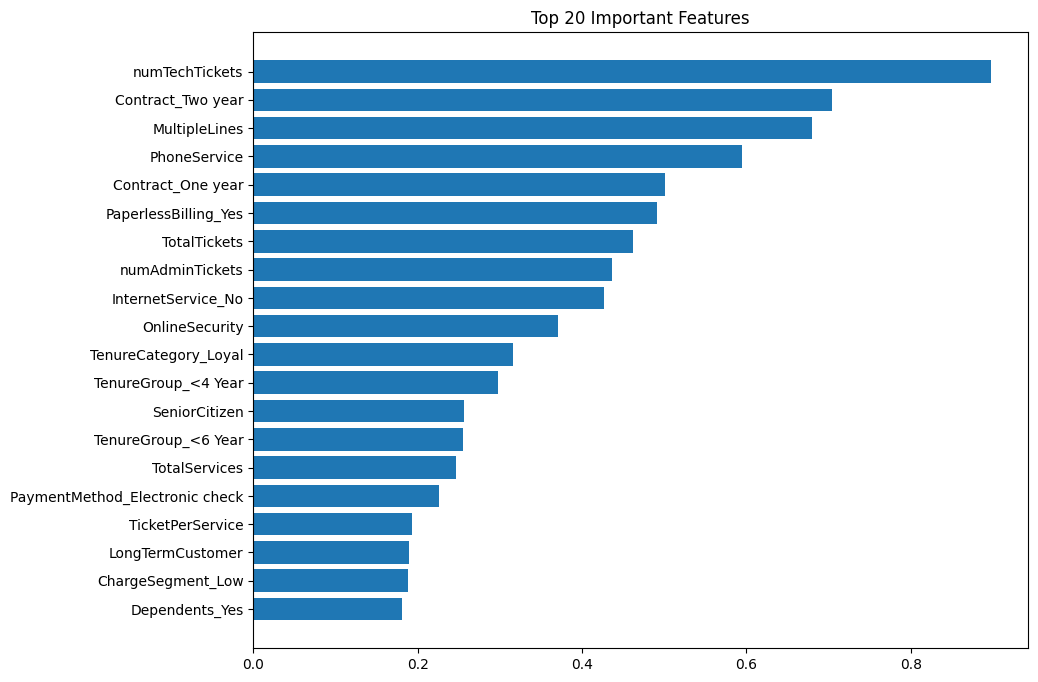

In [37]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

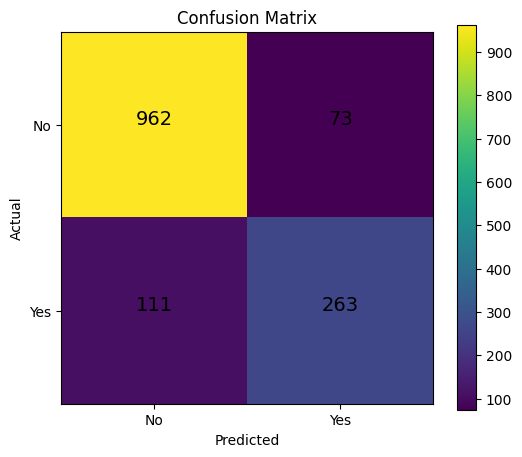

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.colorbar()

plt.xticks([0,1],["No","Yes"])

plt.yticks([0,1],["No","Yes"])

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha="center",fontsize=14)

plt.title("Confusion Matrix")

plt.show()

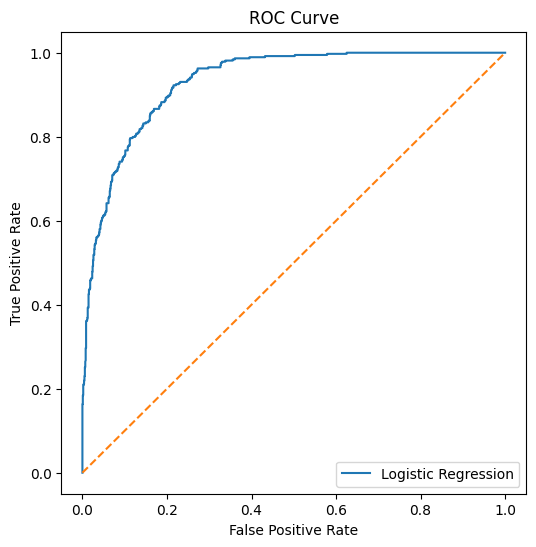

In [39]:
from sklearn.metrics import roc_curve

fpr,tpr,_ = roc_curve(y_test,y_prob_lr)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label="Logistic Regression")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [41]:
import joblib

best_model = lr

joblib.dump(best_model, "models/best_churn_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [43]:
# Predict every customer

predictions = best_model.predict(X)

probabilities = best_model.predict_proba(X)[:, 1]

print("Predictions Created Successfully")

Predictions Created Successfully


In [44]:
# Create a copy of the original dataset

prediction_df = df.copy()

# Add predicted churn
prediction_df["Predicted_Churn"] = predictions

# Add churn probability
prediction_df["Churn_Probability"] = probabilities

prediction_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TotalCharges,numAdminTickets,numTechTickets,Churn,Churn_Flag,TenureGroup,ChargeSegment,Revenue,Predicted_Churn,Churn_Probability
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,29.85,0,0,No,0,<1 Year,Low,29.85,1,0.667888
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,1889.50,0,0,No,0,<3 Year,Medium,1936.30,0,0.017067
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,108.15,0,0,Yes,1,<1 Year,Medium,107.70,0,0.355742
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,1840.75,0,3,No,0,<4 Year,Medium,1903.50,0,0.410812
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,151.65,0,0,Yes,1,<1 Year,High,141.40,1,0.793409


In [45]:
prediction_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TotalCharges,numAdminTickets,numTechTickets,Churn,Churn_Flag,TenureGroup,ChargeSegment,Revenue,Predicted_Churn,Churn_Probability
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,29.85,0,0,No,0,<1 Year,Low,29.85,1,0.667888
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,1889.50,0,0,No,0,<3 Year,Medium,1936.30,0,0.017067
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,108.15,0,0,Yes,1,<1 Year,Medium,107.70,0,0.355742
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,1840.75,0,3,No,0,<4 Year,Medium,1903.50,0,0.410812
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,151.65,0,0,Yes,1,<1 Year,High,141.40,1,0.793409


In [46]:
prediction_df["Predicted_Churn"] = prediction_df["Predicted_Churn"].map({
    0: "No",
    1: "Yes"
})

In [47]:
prediction_df["Risk_Level"] = pd.cut(
    prediction_df["Churn_Probability"],
    bins=[0, 0.40, 0.70, 1.00],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [48]:
prediction_df["Risk_Level"].value_counts()

Risk_Level
Low       4991
High      1037
Medium    1015
Name: count, dtype: int64

In [49]:
prediction_df.to_csv(
    "data/customer_churn_predictions.csv",
    index=False
)

print("Prediction dataset exported successfully!")

Prediction dataset exported successfully!
